In [1]:
import random
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
from IPython.display import clear_output
import time

random.seed(0)
np.random.seed(0)


In [2]:
class SnakeEnv:
    """Grid-of-cells Snake environment."""

    DIRS = [(0, -1), (1, 0), (0, 1), (-1, 0)]  # up, right, down, left

    def __init__(self, grid_size=12):
        self.grid_size = grid_size
        self.reset()

    def reset(self):
        c = self.grid_size // 2
        self.snake = [(c, c), (c - 1, c), (c - 2, c)]
        self.direction = 1  # moving right
        self.score = 0
        self.steps = 0
        self.alive = True
        self._place_food()
        return self.get_state()

    def _place_food(self):
        empty = [(x, y) for x in range(self.grid_size) for y in range(self.grid_size)
                  if (x, y) not in self.snake]
        self.food = random.choice(empty)

    def _is_danger(self, x, y):
        if x < 0 or x >= self.grid_size or y < 0 or y >= self.grid_size:
            return True
        return (x, y) in self.snake

    def get_state(self):
        head = self.snake[0]
        straight_d = self.direction
        left_d = (self.direction + 3) % 4
        right_d = (self.direction + 1) % 4

        def danger_in(d):
            dx, dy = self.DIRS[d]
            return int(self._is_danger(head[0] + dx, head[1] + dy))

        danger_straight = danger_in(straight_d)
        danger_left = danger_in(left_d)
        danger_right = danger_in(right_d)

        food_dx = np.sign(self.food[0] - head[0])
        food_dy = np.sign(self.food[1] - head[1])

        return (danger_straight, danger_left, danger_right,
                self.direction, food_dx, food_dy)

    def step(self, action):
        """action: 0 = straight, 1 = turn left, 2 = turn right"""
        if action == 1:
            self.direction = (self.direction + 3) % 4
        elif action == 2:
            self.direction = (self.direction + 1) % 4

        head = self.snake[0]
        dx, dy = self.DIRS[self.direction]
        nx, ny = head[0] + dx, head[1] + dy

        prev_dist = abs(head[0] - self.food[0]) + abs(head[1] - self.food[1])
        reward = -0.05  # small time penalty

        if (nx < 0 or nx >= self.grid_size or ny < 0 or ny >= self.grid_size
                or (nx, ny) in self.snake):
            self.alive = False
            return self.get_state(), -10.0, True

        self.snake.insert(0, (nx, ny))

        if (nx, ny) == self.food:
            self.score += 1
            reward = 10.0
            self._place_food()
        else:
            self.snake.pop()
            new_dist = abs(nx - self.food[0]) + abs(ny - self.food[1])
            reward += 0.1 if new_dist < prev_dist else -0.15

        self.steps += 1
        done = False
        if self.steps > 300 + self.score * 100:
            self.alive = False
            reward = -10.0
            done = True

        return self.get_state(), reward, done or not self.alive

    def render(self):
        """Text rendering of the grid of cells."""
        grid = [["." for _ in range(self.grid_size)] for _ in range(self.grid_size)]
        for (x, y) in self.snake[1:]:
            grid[y][x] = "o"
        hx, hy = self.snake[0]
        grid[hy][hx] = "H"
        fx, fy = self.food
        grid[fy][fx] = "F"
        return "\n".join(" ".join(row) for row in grid)


In [3]:
class QLearningAgent:
    def __init__(self, n_actions=3, alpha=0.15, gamma=0.9,
                 epsilon=1.0, epsilon_min=0.02, epsilon_decay=0.0006):
        self.n_actions = n_actions
        self.alpha = alpha
        self.gamma = gamma
        self.epsilon = epsilon
        self.epsilon_min = epsilon_min
        self.epsilon_decay = epsilon_decay
        self.Q = defaultdict(lambda: np.zeros(n_actions))

    def choose_action(self, state, greedy=False):
        if not greedy and random.random() < self.epsilon:
            return random.randrange(self.n_actions)
        return int(np.argmax(self.Q[state]))

    def update(self, state, action, reward, next_state, done):
        best_next = 0.0 if done else np.max(self.Q[next_state])
        td_target = reward + self.gamma * best_next
        td_error = td_target - self.Q[state][action]
        self.Q[state][action] += self.alpha * td_error

    def decay_epsilon(self):
        self.epsilon = max(self.epsilon_min, self.epsilon - self.epsilon_decay)


In [4]:
env = SnakeEnv(grid_size=12)
agent = QLearningAgent()

N_EPISODES = 3000
scores = []
best_score = 0

for ep in range(N_EPISODES):
    state = env.reset()
    done = False

    while not done:
        action = agent.choose_action(state)
        next_state, reward, done = env.step(action)
        agent.update(state, action, reward, next_state, done)
        state = next_state

    agent.decay_epsilon()
    scores.append(env.score)
    best_score = max(best_score, env.score)

    if (ep + 1) % 500 == 0:
        avg_last_100 = np.mean(scores[-100:])
        print(f"Episode {ep + 1:5d} | epsilon {agent.epsilon:.3f} | "
              f"avg score (last 100) {avg_last_100:.2f} | best {best_score}")

print("\nTraining done. Best score:", best_score)


Episode   500 | epsilon 0.700 | avg score (last 100) 0.65 | best 3
Episode  1000 | epsilon 0.400 | avg score (last 100) 1.61 | best 7
Episode  1500 | epsilon 0.100 | avg score (last 100) 5.43 | best 21
Episode  2000 | epsilon 0.020 | avg score (last 100) 13.83 | best 34
Episode  2500 | epsilon 0.020 | avg score (last 100) 14.54 | best 34
Episode  3000 | epsilon 0.020 | avg score (last 100) 15.50 | best 36

Training done. Best score: 36


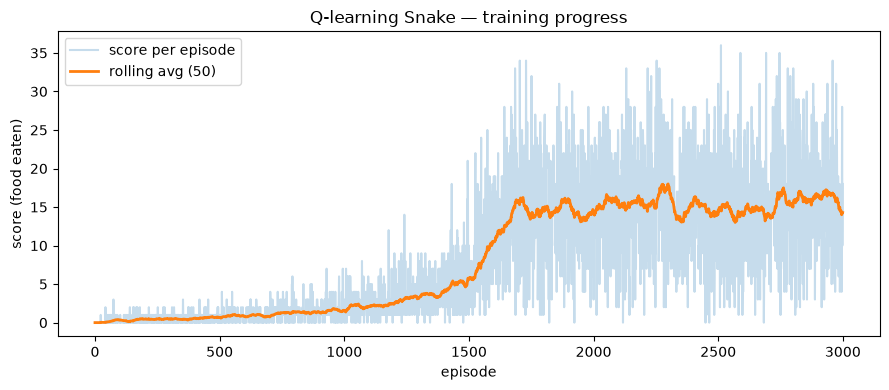

In [5]:
window = 50
rolling_avg = [np.mean(scores[max(0, i - window):i + 1]) for i in range(len(scores))]

plt.figure(figsize=(9, 4))
plt.plot(scores, alpha=0.25, label="score per episode")
plt.plot(rolling_avg, linewidth=2, label=f"rolling avg ({window})")
plt.xlabel("episode")
plt.ylabel("score (food eaten)")
plt.title("Q-learning Snake — training progress")
plt.legend()
plt.tight_layout()
plt.show()


In [6]:
def play_episode(env, agent, max_steps=200, delay=0.15):
    state = env.reset()
    done = False
    step_count = 0

    while not done and step_count < max_steps:
        clear_output(wait=True)
        print(f"Score: {env.score}   Step: {step_count}")
        print(env.render())
        time.sleep(delay)

        action = agent.choose_action(state, greedy=True)
        state, reward, done = env.step(action)
        step_count += 1

    clear_output(wait=True)
    print(f"Final score: {env.score}")
    print(env.render())

play_episode(env, agent)


Final score: 18
. F . . . . . . . . . .
. . . . . . . . . . . .
. . . . . . . . . . . .
. . . . . . . . . . . .
. . . . . . o o o o o .
. . . . . . o o o H o .
. . . . . . o o o o o .
. . . . . . o o o o o .
. . . . . . o . . . . .
. . . . . . . . . . . .
. . . . . . . . . . . .
. . . . . . . . . . . .
